# NIR vein detection test -- skeleton + safest-target point
Tests detection quality on real NIR photos/video from your NoIR Camera Module 2,
**before** writing any Pi code. No training, no GPU needed (CPU is fine).

Pipeline: **NIR frame -> hand ROI -> ridge (vesselness) filter -> thin skeleton ->
branch-point ("conjugated vein") detection -> widest safe point = needle target.**

### About your uploaded training notebook
That notebook trains and runs a **YOLO box detector** (`model.train(...)`, then
`model.predict(...)` printing `xyxy` boxes). It draws rectangles around a vein
region and a confidence score -- that's all it does. It does **not** produce a
skeleton, a centreline, or a needle-target point, and it doesn't know about
branching veins. That's a different, and for this purpose less useful, output
than what's built here: boxes tell you roughly *where*, not the precise
insertion point. You don't need to run that notebook again for this task.

In [1]:
!pip install -q scikit-image scipy opencv-python-headless

## 1. Write the two shared modules

In [2]:
%%writefile vein_postprocess.py
"""
Vein post-processing: probability map -> clean mask -> skeleton -> junctions
-> best straight/thick segment -> needle target point (+ direction).
Pure numpy / scipy / scikit-image / OpenCV (no deep-learning dependency).
"""
import cv2
import numpy as np
from dataclasses import dataclass
from scipy import ndimage as ndi
from skimage.morphology import skeletonize

K8 = np.ones((3, 3), int)
K8[1, 1] = 0


@dataclass
class Target:
    x: int
    y: int
    width_px: float          # local vein diameter (2 x distance transform)
    direction: np.ndarray    # unit vector along the vein (dx, dy)
    dist_to_junction_px: float
    score: float


def clean_mask(prob, thr=0.5, min_area=80):
    m = (prob > thr).astype(np.uint8)
    n, lab, stats, _ = cv2.connectedComponentsWithStats(m, connectivity=8)
    keep = np.zeros(n, bool)
    keep[1:] = stats[1:, cv2.CC_STAT_AREA] >= min_area          # drop tiny blobs (noise)
    m = keep[lab].astype(np.uint8)
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, np.ones((3, 3), np.uint8))
    return m.astype(bool)


def _neighbours(skel):
    return ndi.convolve(skel.astype(int), K8, mode="constant") * skel


def prune_spurs(skel, spur_len=10, passes=2):
    """Remove short side-branches (skeleton 'hairs') that hang off a junction."""
    skel = skel.copy()
    for _ in range(passes):
        nb = _neighbours(skel)
        junc = skel & (nb >= 3)
        zone = cv2.dilate(junc.astype(np.uint8), np.ones((3, 3), np.uint8)).astype(bool)
        branches = skel & ~zone
        lab, n = ndi.label(branches, structure=np.ones((3, 3)))
        endpoints = skel & (nb == 1)
        zone_touch = cv2.dilate(zone.astype(np.uint8), np.ones((3, 3), np.uint8)).astype(bool)
        for i in range(1, n + 1):
            comp = lab == i
            if comp.sum() < spur_len and (comp & endpoints).any() and (comp & zone_touch).any():
                skel[comp] = False
        skel = skeletonize(skel)
    return skel


def analyse(prob, thr=0.5, min_area=80, spur_len=10, junction_pad=6):
    mask = clean_mask(prob, thr, min_area)
    dt = ndi.distance_transform_edt(mask)                 # radius at every vein pixel
    skel = prune_spurs(skeletonize(mask), spur_len)
    nb = _neighbours(skel)
    junctions = skel & (nb >= 3)                          # bifurcations / confluences
    endpoints = skel & (nb == 1)
    k = 2 * junction_pad + 1
    jzone = cv2.dilate(junctions.astype(np.uint8), np.ones((k, k), np.uint8)).astype(bool)
    segments, nseg = ndi.label(skel & ~jzone, structure=np.ones((3, 3)))
    dist_to_j = (ndi.distance_transform_edt(~junctions) if junctions.any()
                 else np.full(mask.shape, 1e6))
    return dict(mask=mask, dt=dt, skel=skel, junctions=junctions, endpoints=endpoints,
                segments=segments, nseg=nseg, dist_to_j=dist_to_j)


def _direction(pts, cy, cx, r=12):
    d = np.hypot(pts[:, 0] - cy, pts[:, 1] - cx)
    p = pts[d <= r].astype(float)
    if len(p) < 3:
        return np.array([1.0, 0.0])
    p -= p.mean(0)
    _, _, vt = np.linalg.svd(p, full_matrices=False)
    v = vt[0]                                             # (dy, dx)
    return np.array([v[1], v[0]])                         # -> (dx, dy)


def proximal_vector(roi, band=2):
    """Unit (dx, dy) pointing from the hand's centre toward the WRIST / forearm.
    The forearm is the part of the hand mask that runs off the edge of the
    frame, so: (mean of the mask pixels touching the frame border) - (mask centroid).
    Falls back to 'up the image' if the mask touches no border."""
    ys, xs = np.nonzero(roi)
    if len(ys) == 0:
        return np.array([0.0, -1.0])
    c = np.array([xs.mean(), ys.mean()])
    edge = np.zeros(roi.shape, bool)
    edge[:band, :] = edge[-band:, :] = edge[:, :band] = edge[:, -band:] = True
    ey, ex = np.nonzero(roi & edge)
    if len(ey) < 10:
        return np.array([0.0, -1.0])
    v = np.array([ex.mean(), ey.mean()]) - c
    n = np.linalg.norm(v)
    return v / n if n > 1e-6 else np.array([0.0, -1.0])


def pick_target(a, min_len=25, min_width=4.0, safe_junction_px=15, end_margin=8, prox=None):
    """Choose the best needle target on the best segment.
    score = width * straightness * length factor; pixel = widest point that is
    far from junctions and from the ends of the segment."""
    best = None
    for i in range(1, a["nseg"] + 1):
        ys, xs = np.nonzero(a["segments"] == i)
        L = len(ys)
        if L < min_len:
            continue
        pts = np.stack([ys, xs], 1)
        w = 2 * a["dt"][ys, xs]
        # straightness: 1.0 = straight line, lower = curvy
        s = np.linalg.svd(pts - pts.mean(0), compute_uv=False)
        straight = 1.0 if s[1] < 1e-6 else float(1 - min(s[1] / s[0], 1.0))
        # keep pixels away from junctions and from segment ends
        far_j = a["dist_to_j"][ys, xs] >= safe_junction_px
        ends = a["endpoints"][ys, xs]
        if ends.any():
            ey, ex = ys[ends], xs[ends]
            far_e = np.min(np.hypot(ys[:, None] - ey[None], xs[:, None] - ex[None]), 1) >= end_margin
        else:
            far_e = np.ones(L, bool)
        # smooth width along the segment to ignore single-pixel noise
        w_s = ndi.uniform_filter1d(w[np.argsort(ys * 10000 + xs)], 5)[np.argsort(np.argsort(ys * 10000 + xs))]
        ok = far_j & far_e & (w_s >= min_width)
        if not ok.any():
            continue
        idx = np.flatnonzero(ok)[np.argmax(w_s[ok])]
        seg_score = float(w_s[idx] * straight * min(L / 60.0, 1.0))
        if best is None or seg_score > best.score:
            d = _direction(pts, ys[idx], xs[idx])
            # the SVD axis has no sign (random flip); point it along `prox`
            # (= toward the wrist) so it is a real needle-insertion direction
            if prox is not None and float(np.dot(d, prox)) < 0:
                d = -d
            best = Target(int(xs[idx]), int(ys[idx]), float(w_s[idx]), d,
                          float(a["dist_to_j"][ys[idx], xs[idx]]), seg_score)
    return best


def draw(img_bgr, a, target, show_junctions=True):
    out = img_bgr.copy()
    out[a["skel"]] = (0, 255, 0)                          # green skeleton
    if show_junctions:
        for y, x in zip(*np.nonzero(a["junctions"])):
            cv2.circle(out, (int(x), int(y)), 3, (0, 165, 255), -1)   # orange = branch point
    if target is not None:
        c = (target.x, target.y)
        cv2.drawMarker(out, c, (0, 0, 255), cv2.MARKER_CROSS, 24, 2)  # red pointer
        tip = (int(round(c[0] + 45 * target.direction[0])), int(round(c[1] + 45 * target.direction[1])))
        cv2.arrowedLine(out, c, tip, (255, 0, 0), 2, cv2.LINE_AA, tipLength=0.3)   # needle direction (blue)
        cv2.putText(out, f"TARGET: ({target.x}, {target.y})  w={target.width_px:.1f}px",
                    (c[0] + 12, c[1] - 12), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)
    return out


class TargetSmoother:
    """Video use: exponential smoothing + only report when stable."""
    def __init__(self, alpha=0.3, jump_px=25):
        self.alpha, self.jump, self.p = alpha, jump_px, None

    def update(self, t):
        if t is None:
            return None if self.p is None else tuple(map(int, self.p))
        q = np.array([t.x, t.y], float)
        if self.p is None or np.linalg.norm(q - self.p) > self.jump:
            self.p = q                                    # re-lock on a new vein
        else:
            self.p = (1 - self.alpha) * self.p + self.alpha * q
        return tuple(map(int, self.p))


Writing vein_postprocess.py


In [3]:
%%writefile vein_nir.py
"""
Vein extraction for TRUE NIR images (Pi NoIR Camera Module 2 + 850nm
illumination). Unlike the earlier vein_classical.py (built as a workaround
for a standard, visible-light-only camera), NIR gives a direct, strong,
single-channel vein signal, so this file is deliberately simpler: no
colour cue is needed or possible (NIR has no usable colour), and no
green-channel trick -- the raw sensor channel already IS the vein signal.

Needs: opencv-python, numpy, scipy, scikit-image
"""
import cv2
import numpy as np
from skimage.filters import sato
from vein_postprocess import analyse, pick_target, draw, TargetSmoother, proximal_vector   # unchanged, reused as-is

WORK_W = 480          # vesselness runs at this width for speed, then is upscaled back


def to_gray(img):
    """Accepts a raw NIR frame in whatever form Picamera2/OpenCV hands it:
    single-channel already, or a 3-channel frame from an RGB-format capture
    (all three channels carry ~the same NIR data, so channel choice barely
    matters -- green is used for consistency with the rest of the code)."""
    if img.ndim == 2:
        return img
    return cv2.split(img)[1]


def hand_roi(gray):
    """NIR hand segmentation: under IR illumination, the hand is usually the
    brightest, smoothest region in frame (skin reflects 850nm well; most
    backgrounds do not). Otsu on brightness + 'largest smooth blob' finds it
    without needing the skin-colour heuristic (colour barely exists in NIR).
    If your setup puts something brighter than the hand in frame (e.g. a
    light-coloured wall lit directly by the IR source), this will need the
    threshold direction flipped -- see the NOTE in the README section of the
    test notebook."""
    h, w = gray.shape
    blur = cv2.GaussianBlur(gray, (0, 0), 3)
    _, m = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, np.ones((15, 15), np.uint8))
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN, np.ones((9, 9), np.uint8))
    n, lab, st, _ = cv2.connectedComponentsWithStats(m, 8)
    if n <= 1:
        return np.zeros((h, w), bool)
    i = 1 + np.argmax(st[1:, cv2.CC_STAT_AREA])
    x, y, bw, bh, area = st[i]
    touches = sum([x <= 1, y <= 1, x + bw >= w - 1, y + bh >= h - 1])
    if area > 0.85 * h * w or touches >= 3:           # whole frame came back "bright" -- untrustworthy
        return np.zeros((h, w), bool)
    m = (lab == i).astype(np.uint8) * 255
    m = cv2.erode(m, np.ones((20, 20), np.uint8))     # stay off the hand's bright silhouette edge
    return m > 0


def enhance(gray):
    g = cv2.createCLAHE(3.0, (8, 8)).apply(gray)       # stronger CLAHE than the visible-light version: NIR veins can still be subtle depending on depth/thickness
    return cv2.bilateralFilter(g, 7, 40, 40)


def vesselness(gray_full, roi_full, sigmas=np.arange(1.3, 5, 0.6)):
    """Multi-scale ridge filter. sigmas start smaller than the visible-light
    version (1.3 vs 2.5) because true NIR vein contrast is strong enough
    that thin veins don't get lost in noise the way visible-light pore
    texture did -- so we don't need to throw away small scales here."""
    h, w = gray_full.shape
    scale = WORK_W / w
    small = cv2.resize(gray_full, (WORK_W, int(h * scale)))
    v = sato(small.astype(np.float32) / 255, sigmas=sigmas, black_ridges=True)   # veins are DARK in NIR
    v = cv2.resize(v, (w, h))
    v = cv2.GaussianBlur(v, (0, 0), 0.6)
    v[~roi_full] = 0
    m = v.max()
    return v / m if m > 1e-6 else v


class FrameAverager:
    """Averages the last N grayscale frames -- cuts sensor noise when the
    camera and the hand are both still."""
    def __init__(self, n=6):
        self.n, self.buf = n, []

    def push(self, gray):
        self.buf.append(gray.astype(np.float32))
        self.buf = self.buf[-self.n:]
        return np.mean(self.buf, axis=0).astype(np.uint8)


def process(raw, avg: FrameAverager, thr_pct=97.5, min_area=50, spur_len=12,
            junction_pad=8, min_len=25, min_width_px=2.5, safe_junction_px=12, end_margin=8,
            needle_toward="wrist"):
    """Returns (analysis_dict_or_None, target_or_None, roi).
    All the *_px / *_pct knobs are the ones to retune once you see real
    footage -- see the tuning cheat-sheet in the test notebook."""
    gray = to_gray(raw)
    roi = hand_roi(gray)
    if roi.sum() < 0.02 * roi.size:
        return None, None, roi
    stable = avg.push(enhance(gray))
    prob = vesselness(stable, roi)
    thr = max(float(np.percentile(prob[roi], thr_pct)), 0.1)
    a = analyse(prob, thr=thr, min_area=min_area, spur_len=spur_len, junction_pad=junction_pad)
    # needle goes along the vein toward the wrist/heart (use needle_toward="fingers" to reverse)
    prox = proximal_vector(roi)
    if needle_toward == "fingers":
        prox = -prox
    t = pick_target(a, min_len=min_len, min_width=min_width_px,
                     safe_junction_px=safe_junction_px, end_margin=end_margin, prox=prox)
    return a, t, roi


Writing vein_nir.py


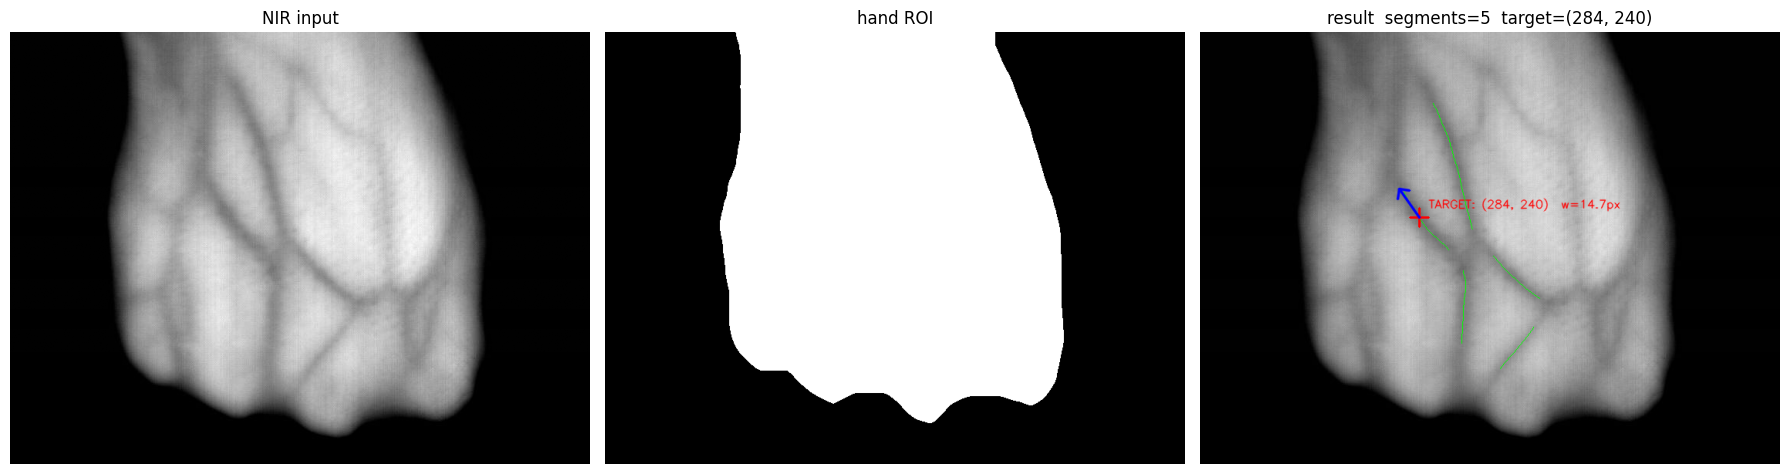

NEEDLE TARGET: (284, 240)  vein width=14.7px  distance to nearest branch=1000000px  axis=[-0.56995676 -0.82167469]


In [4]:
import cv2, matplotlib.pyplot as plt
from vein_nir import process, FrameAverager, to_gray, hand_roi
from vein_postprocess import draw

IMG_PATH = "/kaggle/input/datasets/minhaj099/testv1/person_008_db1_R2_png.rf.1bf43067be0314532bd5758dde172d5b.jpg"     # <- change [NIR_img_path]

raw = cv2.imread(IMG_PATH)
avg = FrameAverager(n=1)          # a still photo has nothing to average over
a, t, roi = process(raw, avg)

fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(to_gray(raw), cmap="gray"); ax[0].set_title("NIR input"); ax[0].axis("off")
ax[1].imshow(roi, cmap="gray"); ax[1].set_title("hand ROI"); ax[1].axis("off")
if a is not None:
    out = draw(cv2.cvtColor(to_gray(raw), cv2.COLOR_GRAY2BGR), a, t)
    ax[2].imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
    ax[2].set_title(f"result  segments={a['nseg']}  target={(t.x, t.y) if t else None}")
else:
    ax[2].imshow(to_gray(raw), cmap="gray"); ax[2].set_title("no hand detected -- check hand_roi")
ax[2].axis("off")
plt.tight_layout(); plt.show()
if t:
    print(f"NEEDLE TARGET: ({t.x}, {t.y})  vein width={t.width_px:.1f}px  "
          f"distance to nearest branch={t.dist_to_junction_px:.0f}px  axis={t.direction}")

## 2. Test on a single NIR image
Upload photos from your NoIR camera as a Kaggle dataset (Add Input), point
`IMG_PATH` at one. Use an OPEN, relaxed hand for the first test.

## 3. Test on several images at once
`IMG_DIR` -> a folder of NIR photos (different hands / distances / exposures),
to see how consistent detection is before trusting it on video.

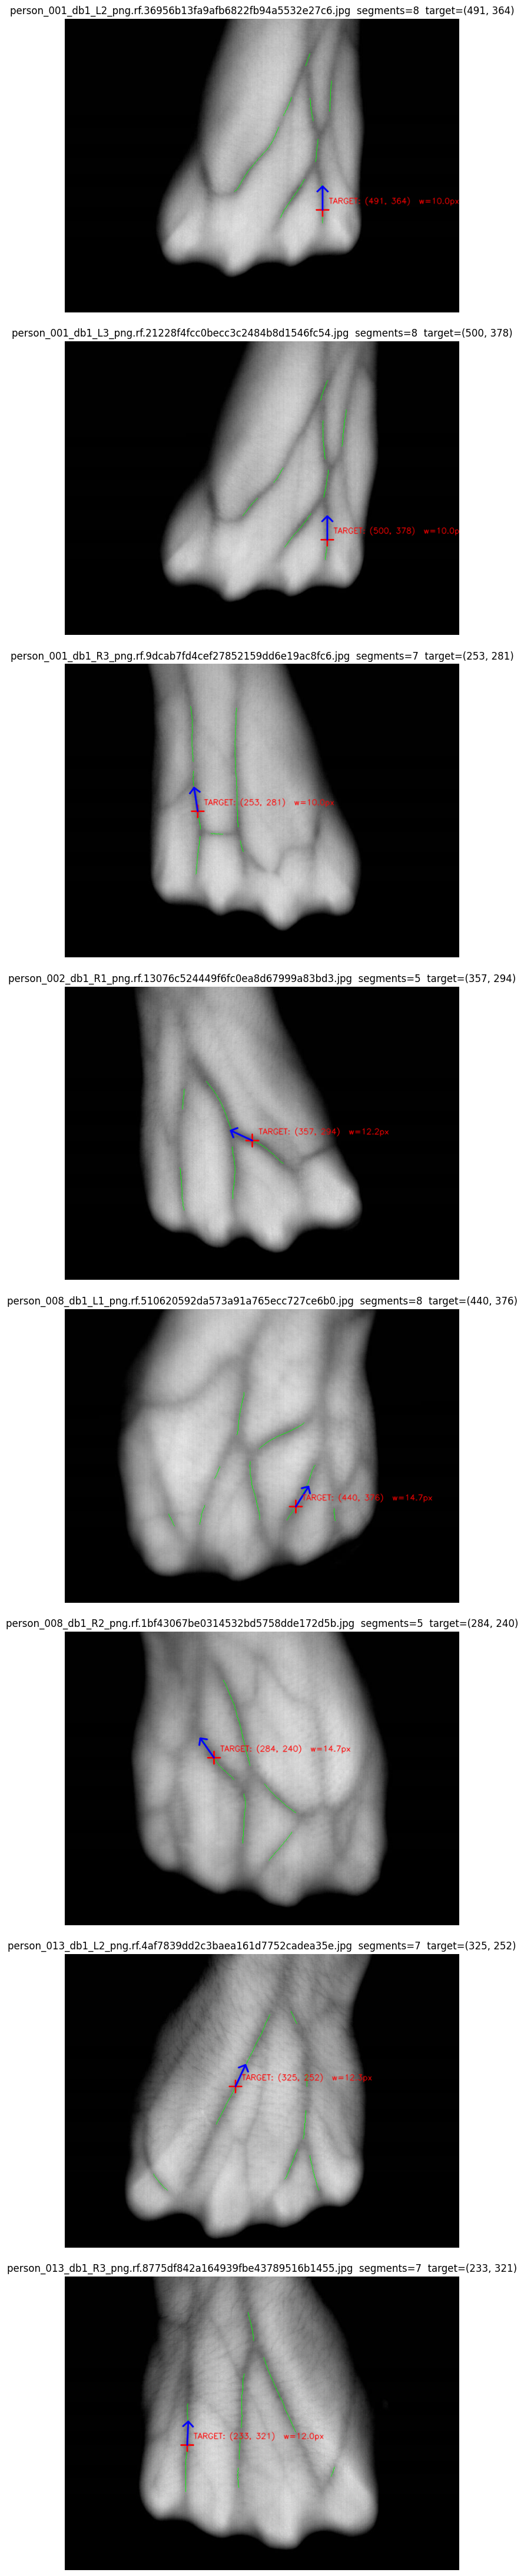

In [5]:
import glob
IMG_DIR = "/kaggle/input/datasets/minhaj099/testv1"     # <- change [NIR_img_dir_path]

paths = sorted(glob.glob(f"{IMG_DIR}/*.png") + glob.glob(f"{IMG_DIR}/*.jpg"))[:8]
fig, ax = plt.subplots(len(paths), 1, figsize=(7, 5.5*len(paths)))
ax = [ax] if len(paths) == 1 else ax
for a_, p in zip(ax, paths):
    raw = cv2.imread(p)
    seg, t, roi = process(raw, FrameAverager(n=1))
    base = cv2.cvtColor(to_gray(raw), cv2.COLOR_GRAY2BGR)
    out = draw(base, seg, t) if seg is not None else base
    a_.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
    a_.set_title(f"{p.split('/')[-1]}  segments={seg['nseg'] if seg else '-'}  target={(t.x,t.y) if t else None}")
    a_.axis("off")
plt.tight_layout(); plt.show()

## 4. Test on a video (mirrors the live Pi loop, including frame averaging)
Upload a short clip recorded on the SAME NoIR camera as a Kaggle dataset. Uses
the identical `process()` + `FrameAverager` the Pi script will use.

In [6]:
VIDEO_PATH = "/kaggle/input/datasets/minhaj099/hand-vid-v4/hand_vid_v4.mp4"     # <- change [NIR_vid_path]
OUT_PATH = "/kaggle/working/vein_nir_out.mp4"

cap = cv2.VideoCapture(VIDEO_PATH)
W, H, FPS = int(cap.get(3)), int(cap.get(4)), cap.get(cv2.CAP_PROP_FPS) or 25
out = cv2.VideoWriter(OUT_PATH, cv2.VideoWriter_fourcc(*"mp4v"), FPS, (W, H))

avg = FrameAverager(n=6)
targets, n_frames = [], 0
while True:
    ok, frame = cap.read()
    if not ok:
        break
    n_frames += 1
    seg, t, roi = process(frame, avg)
    base = cv2.cvtColor(to_gray(frame), cv2.COLOR_GRAY2BGR)
    vis = draw(base, seg, t) if seg is not None else base
    out.write(vis)
    if t:
        targets.append((t.x, t.y))
cap.release(); out.release()
print(f"processed {n_frames} frames -> {OUT_PATH}")
print(f"target found on {len(targets)}/{n_frames} frames ({100*len(targets)/max(n_frames,1):.0f}%)")

processed 250 frames -> /kaggle/working/vein_nir_out.mp4
target found on 1/250 frames (0%)


## 5. Watch the output video

In [7]:
from IPython.display import Video
Video(OUT_PATH, embed=True, width=640)

## 6. Tuning cheat-sheet
All knobs are keyword arguments to `process(raw, avg, ...)` in `vein_nir.py`.

| Symptom | What to change |
|---|---|
| Misses real veins (segments too few / too short) | lower `thr_pct` (e.g. 96), or widen `sigmas` in `vesselness()` |
| Picks up skin creases / non-vein ridges | raise `thr_pct` (e.g. 98.5), or raise `min_width_px` |
| ROI misses the hand, or grabs the background | your background is brighter than the hand under IR -- see NOTE in `hand_roi()`; may need the threshold flipped, or a plain dark backdrop |
| Target sits too close to a branch point | raise `safe_junction_px` |
| Target flickers between frames (video) | raise `FrameAverager(n=...)` |

Once this looks right, copy `vein_nir.py` + `vein_postprocess.py` onto the Pi
unchanged for the live version -- ask for that once you're happy here.